<a href="https://colab.research.google.com/github/PabloTzeliks/titanic-machine-learning/blob/main/TitanicDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Desafio Dataset Titanic**

*   Pandas
*   MatPlotLib
*   Seaborn
*   Scikit-learn

### Implementações

1.   Divisão de Dados para a Prova Real
2.   Avaliação dos Dados com Métricas
3.   Gráficos Personalizados

### Importando Bibliotecas

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import re

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from google.colab import drive

### Filtrando os Dados

*   Convertendo o Sexo
*   Preenchendo Idades Vázias
*   Removendo Classes Inuteis
*   Extraindo Titulos dos Passageiros
*   Agrupando diferentes Titulos com Classificações
*   Criando Tamanhos de Famílias
*   Tratamento de Embarque
*   Tratamento de Tarifa
*   One-Hot Encoding

In [ ]:
def preprocess_data(df):

  # Extraindo Titulos dos Passageiros
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

  # Agrupando Titulos de Passageiros Raros
  df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', \
                                       'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
  df['Title'] = df['Title'].replace('Mlle', 'Miss')
  df['Title'] = df['Title'].replace('Ms', 'Miss')
  df['Title'] = df['Title'].replace('Mme', 'Mrs')

  # Mapeando Titulos dos Passageiros
  title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
  df['Title'] = df['Title'].map(title_mapping)
  df['Title'] = df['Title'].fillna(0)

  # Convertendo Sexo para Números
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

  # Preenchendo idades Vázias com Mediana
  df['Age'] = df['Age'].fillna(df['Age'].median())

  # Definindo Tamanho das Famílias
  df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

  # Flag se está sozinho
  df['IsAlone'] = 0
  df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

  # Tratando Embarque
  freq_port = df.Embarked.dropna().mode()[0]
  df['Embarked'] = df['Embarked'].fillna(freq_port)

  # Tratando Tarifa
  df['Fare'] = df['Fare'].fillna(df['Fare'].median())

  # Convertendo Embarque para padrão One-Hot
  df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarque')

  # Removendo Colunas Inúteis
  drop_elements = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
  df = df.drop(drop_elements, axis=1) # Corrected: assign back the dropped columns

  return df

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1873165669.py:4: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


### Recebendo os Dados

In [ ]:
drive.mount('/content/drive')

# Carregar
train_raw = pd.read_csv('/content/drive/MyDrive/titanic/train.csv')
test_raw = pd.read_csv('/content/drive/MyDrive/titanic/test.csv')

# Guardar ID do Teste
passenger_id = test_raw['PassengerId']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
len_train = len(train_raw)

# Rebendo todos os Dados com Tratamento
all_data = pd.concat([train_raw, test_raw], sort=False).reset_index(drop=True)
all_data_processed = preprocess_data(all_data)

In [ ]:
# Separando
X = all_data_processed[:len_train].drop('Survived', axis=1)
y = all_data_processed[:len_train]['Survived'].astype(int)

X_test_final = all_data_processed[len_train:].drop('Survived', axis=1)

### Divisão de Dados (80/20)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Criação do Modelo

In [ ]:
# Criando o Modelo
model = RandomForestClassifier(n_estimators=500, max_depth=5, random_state=1)

# As colunas não numéricas já devem ter sido removidas pelo preprocess_data corrigido.
# Treinando o Modelo
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=500, random_state=1)

### Avaliação com Métricas

In [ ]:
# Avaliação
predictions_val = model.predict(X_val)

# Acurácia
accuracy = accuracy_score(y_val, predictions_val)

In [ ]:
print("Relatório de Desempenho")
print(f"Acurácia na Validação: {accuracy:.2%}") # Ex: 82.10%
print("\nMatriz de Confusão:")
print(confusion_matrix(y_val, predictions_val))

Relatório de Desempenho
Acurácia na Validação: 82.68%

Matriz de Confusão:
[[92 13]
 [18 56]]


### Gerando Gráficos

/tmp/ipython-input-2069998735.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette="viridis")


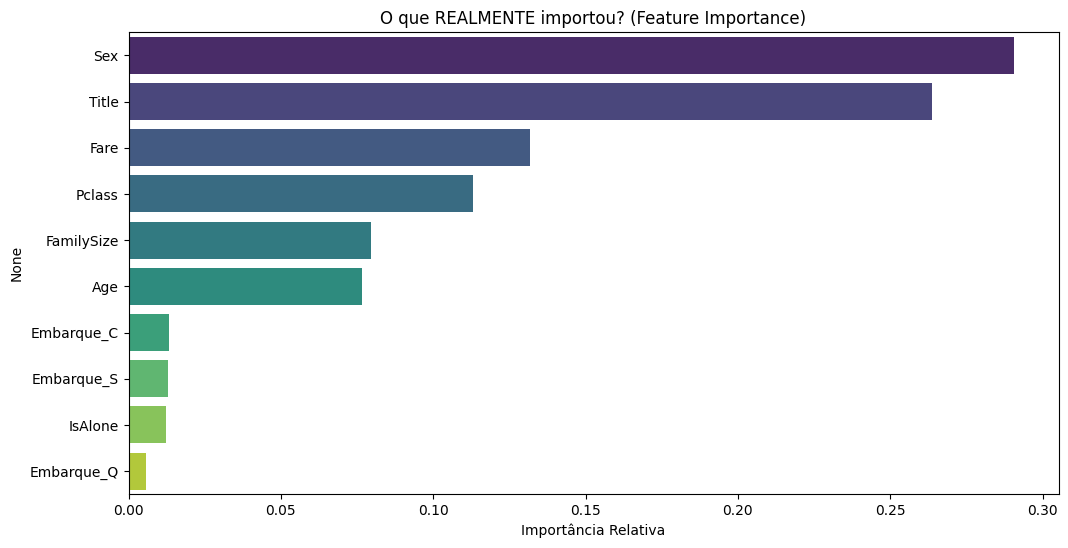

In [ ]:
# O que mais pesou na Decisão?

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances, y=importances.index, palette="viridis")
plt.title("O que REALMENTE importou? (Feature Importance)")
plt.xlabel("Importância Relativa")
plt.show()

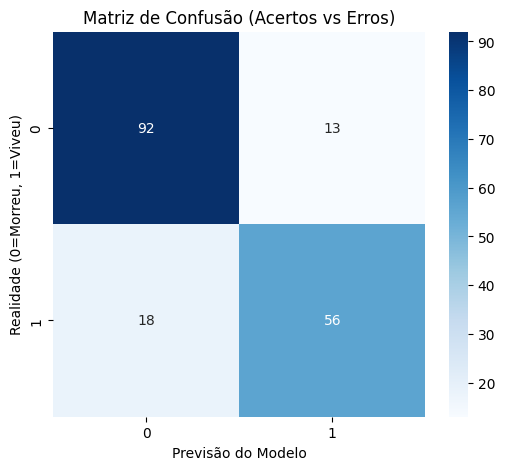

In [ ]:
# Matriz de Confusão
# Analisar onde o Modelo está errando

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, predictions_val), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão (Acertos vs Erros)")
plt.ylabel("Realidade (0=Morreu, 1=Viveu)")
plt.xlabel("Previsão do Modelo")
plt.show()

### Gerando a Previsão Final

In [ ]:
# Treinamento do Modelo Final
model.fit(X, y)

# Gerando a Previsão Final
final_preds = model.predict(X_test_final)

# Montando a Tabela Final como Pedido pelo Kaggle
output = pd.DataFrame({'PassengerId': passenger_id, 'Survived': final_preds})

# Salvando em um arquivo CSV
output.to_csv('submission_pro.csv', index=False)